### Full Simulation Experiment Code (Without Comparison)

Two-stage convex solver
Stage 1: joint A,B,C,L
Stage 2: freeze A,B,C and refit only L with hard rank-r debiasing
n1=120, n2=140, d1=5, d2=6, r_true=3
p_obs=0.3, sigma=0.001

Stage 1 settings:
c_lambda=2.000000e+01
lambda_stage1=1.296148e-01
eta_A=4.375823e+00, eta_B=6.112525e-02, eta_C=5.369087e-02, eta_L=6.000000e-02

Truth feasibility check:
||Z^T B||_F = 5.6847118580321365e-15
||W^T C||_F = 8.392368431038206e-15
||W^T L||_F = 8.51090459495434e-16
||L Z||_F   = 8.057747432051865e-16

True component Frobenius norms:
{'WAZ': 12.734835619648537, 'WBt': 31.320827637539207, 'CZT': 33.941441700078066, 'L': 8.077747210701755}

[Stage 1] Iter    1 | obj = 2.140099e+02 | err_D = 4.7087e-01 | err_A = 4.7917e-01 | err_B = 4.6832e-01 | err_C = 4.7302e-01 | err_L = 5.0059e-01 | rank(L) = 115 | rel_change = 2.123e-01
[Stage 1] Iter   10 | obj = 4.312983e+01 | err_D = 3.9108e-01 | err_A = 3.9743e-01 | err_B = 3.5628e-01 | err_C = 3.7182e-01 | err_L = 9.8752e-01 | rank(L) = 103 | rel_change = 2.099e

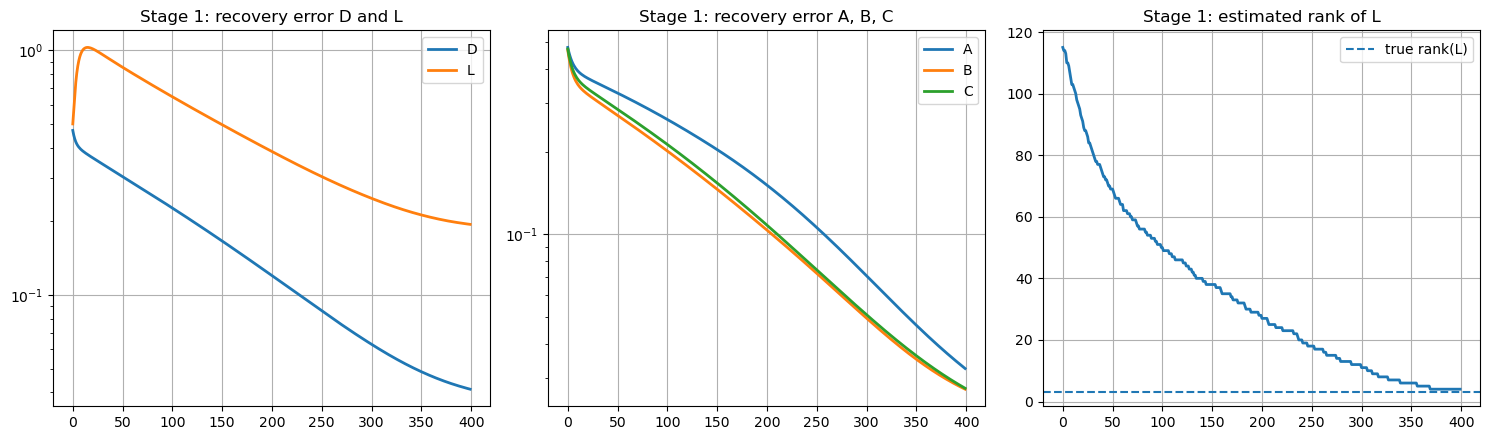

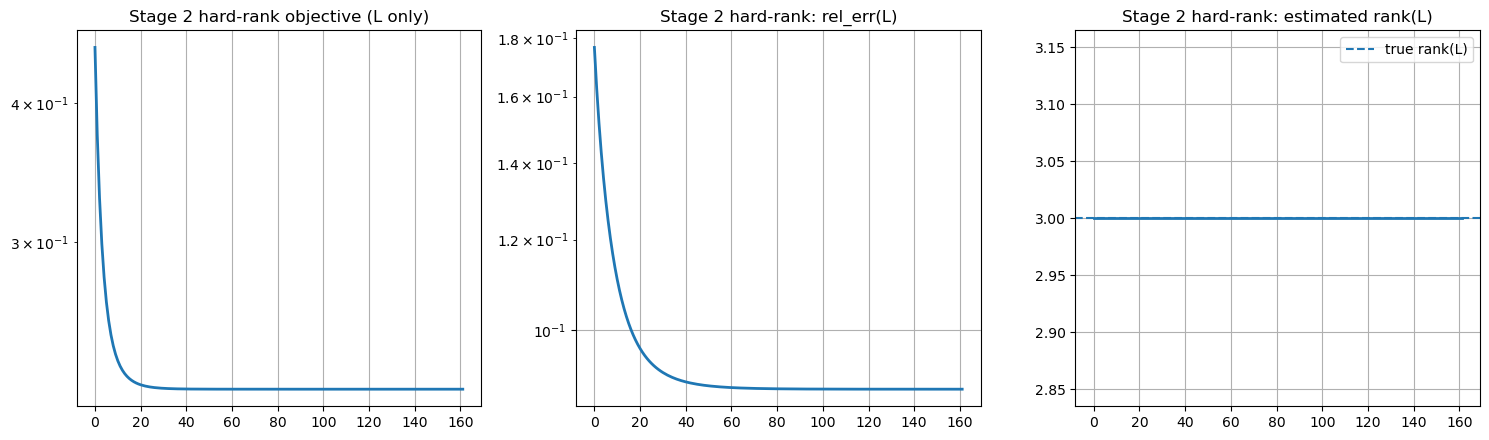

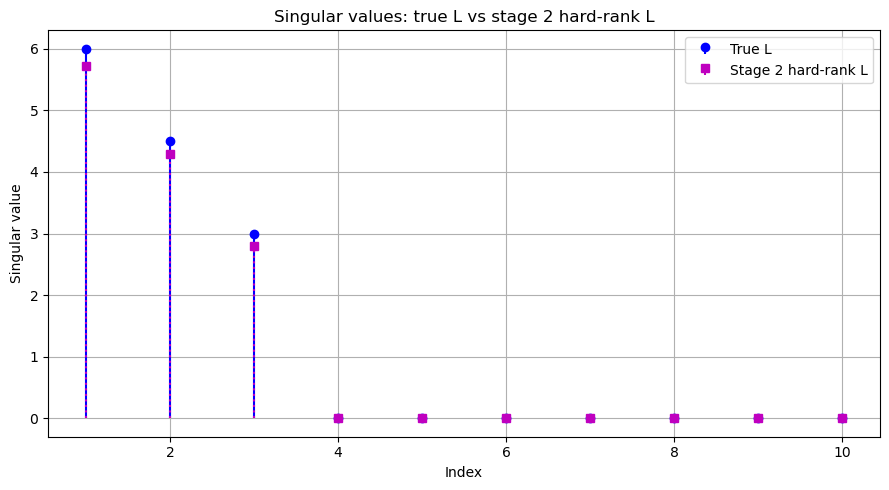

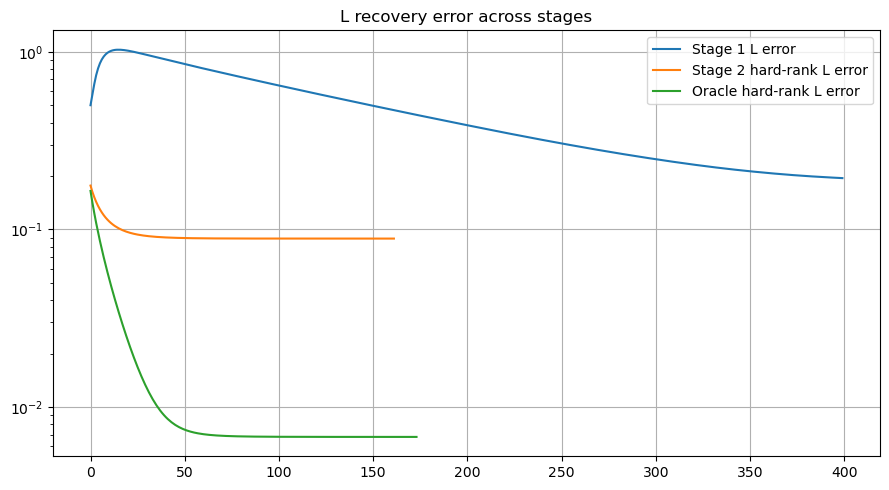

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Two-stage convex solver for the full model
#
#   M* = W A Z^T + W B^T + C Z^T + L
#
# Objective in stage 1:
#   min_{A,B,C,L in R(W,Z)}
#       (1/(2p)) * || P_Omega(WAZ^T + WB^T + CZ^T + L - M_obs) ||_F^2
#       + (lambda/p) * ||L||_*
#
# Stage 2:
#   Freeze A,B,C at their learned stage-1 values, and refit only L
#   using hard rank-r projection (SVP) debiasing.
# ============================================================


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def fro_norm(X):
    return np.linalg.norm(X, ord="fro")


def relative_fro_error(X_hat, X_true, eps=1e-12):
    return fro_norm(X_hat - X_true) / (fro_norm(X_true) + eps)


def projector_onto_colspace(X):
    """
    P_X = X (X^T X)^dagger X^T
    """
    return X @ np.linalg.pinv(X.T @ X) @ X.T


def projector_onto_orthogonal_complement(X):
    """
    P_X_perp = I - P_X
    """
    n = X.shape[0]
    return np.eye(n) - projector_onto_colspace(X)


def project_B_to_feasible(B, PZ_perp):
    return PZ_perp @ B


def project_C_to_feasible(C, PW_perp):
    return PW_perp @ C


def project_L_to_feasible(L, PW_perp, PZ_perp):
    return PW_perp @ L @ PZ_perp


def singular_value_thresholding(Y, tau):
    U, S, Vh = np.linalg.svd(Y, full_matrices=False)
    S_thresh = np.maximum(S - tau, 0.0)
    return U @ np.diag(S_thresh) @ Vh


def singular_value_projection(Y, rank):
    U, S, Vh = np.linalg.svd(Y, full_matrices=False)
    k = min(int(rank), len(S))
    if k <= 0:
        return np.zeros_like(Y)
    return U[:, :k] @ np.diag(S[:k]) @ Vh[:k, :]


def numerical_rank(X, rel_thresh=1e-3):
    s = np.linalg.svd(X, compute_uv=False)
    if s.size == 0 or s[0] <= 1e-15:
        return 0
    return int(np.sum(s > rel_thresh * s[0]))


def recommended_lambda(sigma, n1, n2, p_obs, c_lambda=5.0):
    """
    Theorem-style scale: lambda ~ C * sigma * sqrt((n1 v n2) * p).
    Tune c_lambda in [2, 10] depending on noise level.
    """
    return c_lambda * sigma * np.sqrt(max(n1, n2) * p_obs)


# ------------------------------------------------------------
# Model pieces
# ------------------------------------------------------------
def component_interaction(W, Z, A):
    return W @ A @ Z.T


def component_B(W, B):
    return W @ B.T


def component_C(C, Z):
    return C @ Z.T


def compose_matrix(W, Z, A, B, C, L):
    return component_interaction(W, Z, A) + component_B(W, B) + component_C(C, Z) + L


def component_norms(W, Z, A, B, C, L):
    return {
        "WAZ": fro_norm(component_interaction(W, Z, A)),
        "WBt": fro_norm(component_B(W, B)),
        "CZT": fro_norm(component_C(C, Z)),
        "L": fro_norm(L),
    }


# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------
def scaled_relative_perturbation(base, noise, rel_level=0.5, eps=1e-12):
    base_norm = fro_norm(base)
    noise_norm = fro_norm(noise)

    if noise_norm < eps:
        return base.copy()

    if base_norm < eps:
        return noise.copy()

    alpha = rel_level * base_norm / (noise_norm + eps)
    return base + alpha * noise


def initialize_parameters(init_mode, A_true, B_true, C_true, L_true, W, Z, rng):
    """
    Supported modes:
        - "near_truth"
        - "random_feasible"
    """
    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    if init_mode == "near_truth":
        rel_level = 0.5

        E_A = rng.standard_normal(size=A_true.shape)
        A0 = scaled_relative_perturbation(A_true, E_A, rel_level=rel_level)

        E_B = rng.standard_normal(size=B_true.shape)
        E_B_feas = project_B_to_feasible(E_B, PZ_perp)
        B0 = scaled_relative_perturbation(B_true, E_B_feas, rel_level=rel_level)
        B0 = project_B_to_feasible(B0, PZ_perp)

        E_C = rng.standard_normal(size=C_true.shape)
        E_C_feas = project_C_to_feasible(E_C, PW_perp)
        C0 = scaled_relative_perturbation(C_true, E_C_feas, rel_level=rel_level)
        C0 = project_C_to_feasible(C0, PW_perp)

        E_L = rng.standard_normal(size=L_true.shape)
        E_L_feas = project_L_to_feasible(E_L, PW_perp, PZ_perp)
        L0 = scaled_relative_perturbation(L_true, E_L_feas, rel_level=rel_level)
        L0 = project_L_to_feasible(L0, PW_perp, PZ_perp)

    elif init_mode == "random_feasible":
        A0 = rng.standard_normal(size=A_true.shape)
        B0 = project_B_to_feasible(rng.standard_normal(size=B_true.shape), PZ_perp)
        C0 = project_C_to_feasible(rng.standard_normal(size=C_true.shape), PW_perp)
        L0 = project_L_to_feasible(rng.standard_normal(size=L_true.shape), PW_perp, PZ_perp)
    else:
        raise ValueError("init_mode must be 'near_truth' or 'random_feasible'")

    return A0, B0, C0, L0


def compute_step_sizes(W, Z, p_obs, cA=0.3, cB=0.3, cC=0.3, cL=0.2):
    """
    Conservative blockwise step sizes for stage 1.
    """
    n1 = W.shape[0]

    op_W = np.linalg.norm(W.T @ W, 2)
    op_Z = np.linalg.norm(Z.T @ Z, 2)

    L_A = (op_W * op_Z) / (n1 * p_obs)
    L_B = op_W / p_obs
    L_C = op_Z / p_obs
    L_L = 1.0 / p_obs

    eta_A = cA / (L_A + 1e-12)
    eta_B = cB / (L_B + 1e-12)
    eta_C = cC / (L_C + 1e-12)
    eta_L = cL / (L_L + 1e-12)

    return eta_A, eta_B, eta_C, eta_L


def compute_L_only_step_size(p_obs, cL=0.8):
    """
    For the L-only residual refit:
        smooth part = (1/(2p)) || P_Omega(L - R_obs) ||_F^2
    gradient Lipschitz constant is 1/p.
    """
    return cL * p_obs


# ------------------------------------------------------------
# Simulation
# ------------------------------------------------------------
def generate_feasible_truth(
    n1, n2, d1, d2, r_true, rng,
    scale_A=1.0, scale_B=1.0, scale_C=1.0, scale_L=1.0
):
    """
    Generate W, Z and true parameters satisfying:
        Z^T B = 0
        W^T C = 0
        W^T L = 0
        L Z   = 0
    """
    W = rng.standard_normal((n1, d1))
    Z = rng.standard_normal((n2, d2))

    W = W / np.sqrt(n1)
    Z = Z / np.sqrt(n2)

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    A_true = scale_A * rng.standard_normal((d1, d2))

    B_raw = rng.standard_normal((n2, d1))
    B_true = scale_B * project_B_to_feasible(B_raw, PZ_perp)

    C_raw = rng.standard_normal((n1, d2))
    C_true = scale_C * project_C_to_feasible(C_raw, PW_perp)

    U0 = rng.standard_normal((n1, r_true))
    V0 = rng.standard_normal((n2, r_true))
    U_feas = PW_perp @ U0
    V_feas = PZ_perp @ V0

    U_true, _ = np.linalg.qr(U_feas)
    V_true, _ = np.linalg.qr(V_feas)

    sing_vals = np.linspace(2.0, 1.0, r_true)
    Sigma = np.diag(scale_L * sing_vals)
    L_true = U_true[:, :r_true] @ Sigma @ V_true[:, :r_true].T
    L_true = project_L_to_feasible(L_true, PW_perp, PZ_perp)

    return W, Z, A_true, B_true, C_true, L_true


def generate_observed_data(M_true, p_obs, sigma, rng):
    noise = rng.normal(0.0, sigma, size=M_true.shape)
    M_noisy = M_true + noise
    mask = (rng.random(M_true.shape) < p_obs).astype(float)
    M_obs = mask * M_noisy
    return M_obs, mask


# ------------------------------------------------------------
# Objectives and diagnostics
# ------------------------------------------------------------
def objective_value_full(A, B, C, L, W, Z, M_obs, mask, p_obs, lambda_val):
    D = compose_matrix(W, Z, A, B, C, L)
    R = mask * (D - M_obs)
    nuc_L = np.sum(np.linalg.svd(L, compute_uv=False))
    return (0.5 / p_obs) * np.sum(R ** 2) + (lambda_val / p_obs) * nuc_L


def objective_value_L_only(L, R_ABC_obs, mask, p_obs, lambda_val=0.0):
    resid = mask * (L - R_ABC_obs)
    nuc_L = np.sum(np.linalg.svd(L, compute_uv=False))
    return (0.5 / p_obs) * np.sum(resid ** 2) + (lambda_val / p_obs) * nuc_L


def check_feasibility(B, C, L, W, Z):
    print("||Z^T B||_F =", fro_norm(Z.T @ B))
    print("||W^T C||_F =", fro_norm(W.T @ C))
    print("||W^T L||_F =", fro_norm(W.T @ L))
    print("||L Z||_F   =", fro_norm(L @ Z))


# ------------------------------------------------------------
# Stage 1: Joint full-model solver
# ------------------------------------------------------------
def solve_full_model_convex_stage1(
    M_obs,
    mask,
    W,
    Z,
    A_true,
    B_true,
    C_true,
    L_true,
    lambda_val,
    init_mode="random feasible",
    max_iter=500,
    tol=1e-7,
    min_iter_before_stop=30,
    verbose=True,
    rng=None,
    cA=0.3,
    cB=0.3,
    cC=0.3,
    cL=0.2,
):
    """
    Stage 1:
      joint estimation of A,B,C,L
    """
    if rng is None:
        rng = np.random.default_rng(0)

    n1 = W.shape[0]
    p_obs = float(np.mean(mask))

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    eta_A, eta_B, eta_C, eta_L = compute_step_sizes(W, Z, p_obs, cA=cA, cB=cB, cC=cC, cL=cL)

    A, B, C, L = initialize_parameters(
        init_mode=init_mode,
        A_true=A_true,
        B_true=B_true,
        C_true=C_true,
        L_true=L_true,
        W=W,
        Z=Z,
        rng=rng
    )

    M_true = compose_matrix(W, Z, A_true, B_true, C_true, L_true)

    stats = {
        "obj": [],
        "err_A": [],
        "err_B": [],
        "err_C": [],
        "err_L": [],
        "err_D": [],
        "rank_L": [],
        "feas_B": [],
        "feas_C": [],
        "feas_L_left": [],
        "feas_L_right": [],
        "eta_A": eta_A,
        "eta_B": eta_B,
        "eta_C": eta_C,
        "eta_L": eta_L,
    }

    for t in range(max_iter):
        A_old = A.copy()
        B_old = B.copy()
        C_old = C.copy()
        L_old = L.copy()

        # ---- A update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        grad_A = (W.T @ R @ Z) / p_obs
        A = A - (eta_A / n1) * grad_A

        # ---- B update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        grad_B = (R.T @ W) / p_obs
        B = project_B_to_feasible(B - eta_B * grad_B, PZ_perp)

        # ---- C update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        grad_C = (R @ Z) / p_obs
        C = project_C_to_feasible(C - eta_C * grad_C, PW_perp)

        # ---- L update ----
        D = compose_matrix(W, Z, A, B, C, L)
        R = mask * (D - M_obs)
        G_L = L - eta_L * (R / p_obs)
        G_L = project_L_to_feasible(G_L, PW_perp, PZ_perp)
        L = singular_value_thresholding(G_L, eta_L * lambda_val / p_obs)
        L = project_L_to_feasible(L, PW_perp, PZ_perp)

        # diagnostics
        D_new = compose_matrix(W, Z, A, B, C, L)
        obj = objective_value_full(A, B, C, L, W, Z, M_obs, mask, p_obs, lambda_val)

        err_A = relative_fro_error(A, A_true)
        err_B = relative_fro_error(B, B_true)
        err_C = relative_fro_error(C, C_true)
        err_L = relative_fro_error(L, L_true)
        err_D = relative_fro_error(D_new, M_true)

        feas_B = fro_norm(Z.T @ B)
        feas_C = fro_norm(W.T @ C)
        feas_L_left = fro_norm(W.T @ L)
        feas_L_right = fro_norm(L @ Z)

        stats["obj"].append(obj)
        stats["err_A"].append(err_A)
        stats["err_B"].append(err_B)
        stats["err_C"].append(err_C)
        stats["err_L"].append(err_L)
        stats["err_D"].append(err_D)
        stats["rank_L"].append(numerical_rank(L))
        stats["feas_B"].append(feas_B)
        stats["feas_C"].append(feas_C)
        stats["feas_L_left"].append(feas_L_left)
        stats["feas_L_right"].append(feas_L_right)

        rel_change_A = fro_norm(A - A_old) / (fro_norm(A_old) + 1e-12)
        rel_change_B = fro_norm(B - B_old) / (fro_norm(B_old) + 1e-12)
        rel_change_C = fro_norm(C - C_old) / (fro_norm(C_old) + 1e-12)
        rel_change_L = fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12)
        rel_change = max(rel_change_A, rel_change_B, rel_change_C, rel_change_L)

        if verbose and ((t + 1) % 10 == 0 or t == 0):
            print(
                f"[Stage 1] Iter {t+1:4d} | "
                f"obj = {obj:.6e} | "
                f"err_D = {err_D:.4e} | "
                f"err_A = {err_A:.4e} | "
                f"err_B = {err_B:.4e} | "
                f"err_C = {err_C:.4e} | "
                f"err_L = {err_L:.4e} | "
                f"rank(L) = {stats['rank_L'][-1]} | "
                f"rel_change = {rel_change:.3e}"
            )

        if not np.isfinite(obj):
            print(f"[Stage 1] Diverged at iteration {t+1}: objective is not finite.")
            break

        if (t + 1 >= min_iter_before_stop) and (rel_change < tol):
            print(f"[Stage 1] Converged at iteration {t+1}")
            break

    return A, B, C, L, stats


# ------------------------------------------------------------
# Stage 2 Freeze A,B,C and refit only L using hard-rank debiasing
# ------------------------------------------------------------
def refit_L_only_stage2(
    M_obs,
    mask,
    W,
    Z,
    A_fixed,
    B_fixed,
    C_fixed,
    L_init,
    L_true,
    rank_refit=None,
    max_iter=400,
    tol=1e-7,
    min_iter_before_stop=30,
    verbose=True,
    cL_refit=0.8,
):
    p_obs = float(np.mean(mask))

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    # fixed structured part
    ABC_fit = component_interaction(W, Z, A_fixed) + component_B(W, B_fixed) + component_C(C_fixed, Z)

    # observed residual matrix for L-only problem
    R_ABC_obs = M_obs - mask * ABC_fit

    eta_L = compute_L_only_step_size(p_obs, cL=cL_refit)

    L = project_L_to_feasible(L_init.copy(), PW_perp, PZ_perp)

    if rank_refit is None:
        rank_refit = numerical_rank(L_init)

    stats = {
        "obj": [],
        "err_L": [],
        "rank_L": [],
        "feas_L_left": [],
        "feas_L_right": [],
        "eta_L": eta_L,
    }

    for t in range(max_iter):
        L_old = L.copy()

        grad = mask * (L - R_ABC_obs) / p_obs
        G = L - eta_L * grad
        G = project_L_to_feasible(G, PW_perp, PZ_perp)

        L = singular_value_projection(G, rank_refit)
        L = project_L_to_feasible(L, PW_perp, PZ_perp)

        obj = objective_value_L_only(L, R_ABC_obs, mask, p_obs, 0.0)
        err_L = relative_fro_error(L, L_true)
        rank_L = numerical_rank(L)
        feas_L_left = fro_norm(W.T @ L)
        feas_L_right = fro_norm(L @ Z)

        stats["obj"].append(obj)
        stats["err_L"].append(err_L)
        stats["rank_L"].append(rank_L)
        stats["feas_L_left"].append(feas_L_left)
        stats["feas_L_right"].append(feas_L_right)

        rel_change = fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12)

        if verbose and ((t + 1) % 10 == 0 or t == 0):
            print(
                f"[Stage 2/hard-rank({rank_refit})] Iter {t+1:4d} | "
                f"obj = {obj:.6e} | "
                f"err_L = {err_L:.4e} | "
                f"rank(L) = {rank_L} | "
                f"rel_change = {rel_change:.3e}"
            )

        if not np.isfinite(obj):
            print(f"[Stage 2] Diverged at iteration {t+1}: objective is not finite.")
            break

        if (t + 1 >= min_iter_before_stop) and (rel_change < tol):
            print(f"[Stage 2/hard_rank] Converged at iteration {t+1}")
            break

    return L, stats


# ------------------------------------------------------------
# Oracle residual baseline for debugging L recovery
# ------------------------------------------------------------
def recover_L_oracle_from_true_ABC(
    M_obs,
    mask,
    W,
    Z,
    A_true,
    B_true,
    C_true,
    L_init,
    L_true,
    rank_refit=None,
    max_iter=400,
    verbose=True,
):
    return refit_L_only_stage2(
        M_obs=M_obs,
        mask=mask,
        W=W,
        Z=Z,
        A_fixed=A_true,
        B_fixed=B_true,
        C_fixed=C_true,
        L_init=L_init,
        L_true=L_true,
        rank_refit=rank_refit,
        max_iter=max_iter,
        verbose=verbose,
    )


# ------------------------------------------------------------
# Main experiment
# ------------------------------------------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(31)

    n1 = 120
    n2 = 140
    d1 = 5
    d2 = 6
    r_true = 3

    p_obs = 0.30
    sigma = 1e-3

    # signal scales
    scale_A = 2.0
    scale_B = 1.2
    scale_C = 1.2
    scale_L = 3.0

    # generate truth
    W, Z, A_true, B_true, C_true, L_true = generate_feasible_truth(
        n1=n1,
        n2=n2,
        d1=d1,
        d2=d2,
        r_true=r_true,
        rng=rng,
        scale_A=scale_A,
        scale_B=scale_B,
        scale_C=scale_C,
        scale_L=scale_L,
    )

    M_true = compose_matrix(W, Z, A_true, B_true, C_true, L_true)
    M_obs, mask = generate_observed_data(M_true, p_obs=p_obs, sigma=sigma, rng=rng)

    # --------------------------
    # Stage 1 settings
    # --------------------------
    c_lambda = 20.0
    lambda_stage1 = recommended_lambda(
        sigma=sigma,
        n1=n1,
        n2=n2,
        p_obs=p_obs,
        c_lambda=c_lambda,
    )
    cA = 0.3
    cB = 0.3
    cC = 0.3
    cL = 0.2

    eta_A, eta_B, eta_C, eta_L = compute_step_sizes(W, Z, p_obs, cA=cA, cB=cB, cC=cC, cL=cL)

    print("===================================================")
    print("Two-stage convex solver")
    print("Stage 1: joint A,B,C,L")
    print("Stage 2: freeze A,B,C and refit only L with hard rank-r debiasing")
    print("===================================================")
    print(f"n1={n1}, n2={n2}, d1={d1}, d2={d2}, r_true={r_true}")
    print(f"p_obs={p_obs}, sigma={sigma}")
    print()
    print("Stage 1 settings:")
    print(f"c_lambda={c_lambda:.6e}")
    print(f"lambda_stage1={lambda_stage1:.6e}")
    print(f"eta_A={eta_A:.6e}, eta_B={eta_B:.6e}, eta_C={eta_C:.6e}, eta_L={eta_L:.6e}")
    print()

    print("Truth feasibility check:")
    check_feasibility(B_true, C_true, L_true, W, Z)
    print()

    true_comp_norms = component_norms(W, Z, A_true, B_true, C_true, L_true)
    print("True component Frobenius norms:")
    print(true_comp_norms)
    print()

    # --------------------------
    # Stage 1
    # --------------------------
    A_hat1, B_hat1, C_hat1, L_hat1, stats1 = solve_full_model_convex_stage1(
        M_obs=M_obs,
        mask=mask,
        W=W,
        Z=Z,
        A_true=A_true,
        B_true=B_true,
        C_true=C_true,
        L_true=L_true,
        lambda_val=lambda_stage1,
        init_mode="near_truth",
        max_iter=400,
        tol=1e-7,
        min_iter_before_stop=30,
        verbose=True,
        rng=np.random.default_rng(123),
        cA=cA,
        cB=cB,
        cC=cC,
        cL=cL,
    )

    D_hat1 = compose_matrix(W, Z, A_hat1, B_hat1, C_hat1, L_hat1)

    print("\nStage 1 final feasibility check:")
    check_feasibility(B_hat1, C_hat1, L_hat1, W, Z)

    print("\nStage 1 final relative errors:")
    print(f"rel_err(A) = {relative_fro_error(A_hat1, A_true):.6f}")
    print(f"rel_err(B) = {relative_fro_error(B_hat1, B_true):.6f}")
    print(f"rel_err(C) = {relative_fro_error(C_hat1, C_true):.6f}")
    print(f"rel_err(L) = {relative_fro_error(L_hat1, L_true):.6f}")
    print(f"rel_err(D) = {relative_fro_error(D_hat1, M_true):.6f}")

    print("\nStage 1 ranks:")
    print(f"true rank(L)      = {numerical_rank(L_true)}")
    print(f"estimated rank(L) = {numerical_rank(L_hat1)}")

    print("\nStage 1 estimated component Frobenius norms:")
    print(component_norms(W, Z, A_hat1, B_hat1, C_hat1, L_hat1))

    # --------------------------
    # Stage 2 settings
    # --------------------------
    cL_refit = 0.8
    eta_L_refit = compute_L_only_step_size(p_obs, cL=cL_refit)

    print()
    print("Stage 2 settings:")
    print(f"rank_refit={r_true}")
    print(f"eta_L_refit={eta_L_refit:.6e}")
    print()

    # --------------------------
    # Stage 2: hard-rank debias refit
    # --------------------------
    L_hat2_hard, stats2_hard = refit_L_only_stage2(
        M_obs=M_obs,
        mask=mask,
        W=W,
        Z=Z,
        A_fixed=A_hat1,
        B_fixed=B_hat1,
        C_fixed=C_hat1,
        L_init=L_hat1,
        L_true=L_true,
        rank_refit=r_true,
        max_iter=300,
        tol=1e-7,
        min_iter_before_stop=30,
        verbose=True,
        cL_refit=cL_refit,
    )

    D_hat2_hard = compose_matrix(W, Z, A_hat1, B_hat1, C_hat1, L_hat2_hard)

    print("\nStage 2 hard-rank final feasibility check:")
    check_feasibility(B_hat1, C_hat1, L_hat2_hard, W, Z)

    print("\nStage 2 hard-rank final relative errors (A,B,C frozen from stage 1):")
    print(f"rel_err(A) = {relative_fro_error(A_hat1, A_true):.6f}")
    print(f"rel_err(B) = {relative_fro_error(B_hat1, B_true):.6f}")
    print(f"rel_err(C) = {relative_fro_error(C_hat1, C_true):.6f}")
    print(f"rel_err(L) = {relative_fro_error(L_hat2_hard, L_true):.6f}")
    print(f"rel_err(D) = {relative_fro_error(D_hat2_hard, M_true):.6f}")

    print("\nStage 2 hard-rank ranks:")
    print(f"true rank(L)      = {numerical_rank(L_true)}")
    print(f"estimated rank(L) = {numerical_rank(L_hat2_hard)}")

    print("\nStage 2 hard-rank estimated component Frobenius norms:")
    print(component_norms(W, Z, A_hat1, B_hat1, C_hat1, L_hat2_hard))

    # --------------------------
    # Oracle L-only baseline
    # --------------------------
    L_oracle, stats_oracle = recover_L_oracle_from_true_ABC(
        M_obs=M_obs,
        mask=mask,
        W=W,
        Z=Z,
        A_true=A_true,
        B_true=B_true,
        C_true=C_true,
        L_init=L_hat1,
        L_true=L_true,
        rank_refit=r_true,
        max_iter=300,
        verbose=True,
    )

    print("\nOracle hard-rank L recovery:")
    print(f"rel_err(L_oracle) = {relative_fro_error(L_oracle, L_true):.6f}")

    # --------------------------------------------------------
    # Plots: Stage 1
    # --------------------------------------------------------
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

    axs[0].plot(stats1["err_D"], lw=2, label="D")
    axs[0].plot(stats1["err_L"], lw=2, label="L")
    axs[0].set_title("Stage 1: recovery error D and L")
    axs[0].set_yscale("log")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(stats1["err_A"], lw=2, label="A")
    axs[1].plot(stats1["err_B"], lw=2, label="B")
    axs[1].plot(stats1["err_C"], lw=2, label="C")
    axs[1].set_title("Stage 1: recovery error A, B, C")
    axs[1].set_yscale("log")
    axs[1].legend()
    axs[1].grid(True)

    axs[2].plot(stats1["rank_L"], lw=2)
    axs[2].axhline(numerical_rank(L_true), linestyle="--", label="true rank(L)")
    axs[2].set_title("Stage 1: estimated rank of L")
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Plots: Stage 2 hard-rank
    # --------------------------------------------------------
    fig2, axs2 = plt.subplots(1, 3, figsize=(15, 4.5))

    axs2[0].plot(stats2_hard["obj"], lw=2)
    axs2[0].set_title("Stage 2 hard-rank objective (L only)")
    axs2[0].set_yscale("log")
    axs2[0].grid(True)

    axs2[1].plot(stats2_hard["err_L"], lw=2)
    axs2[1].set_title("Stage 2 hard-rank: rel_err(L)")
    axs2[1].set_yscale("log")
    axs2[1].grid(True)

    axs2[2].plot(stats2_hard["rank_L"], lw=2)
    axs2[2].axhline(numerical_rank(L_true), linestyle="--", label="true rank(L)")
    axs2[2].set_title("Stage 2 hard-rank: estimated rank(L)")
    axs2[2].legend()
    axs2[2].grid(True)

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Singular value comparison: true L vs stage 2 hard-rank L
    # --------------------------------------------------------
    s_true = np.linalg.svd(L_true, compute_uv=False)
    s_hat2_hard = np.linalg.svd(L_hat2_hard, compute_uv=False)
    k = min(10, len(s_true), len(s_hat2_hard))

    plt.figure(figsize=(9, 5))
    plt.stem(range(1, k + 1), s_true[:k], linefmt='b-', markerfmt='bo', basefmt=' ', label='True L')
    plt.stem(range(1, k + 1), s_hat2_hard[:k], linefmt='m:', markerfmt='ms', basefmt=' ', label='Stage 2 hard-rank L')
    plt.title("Singular values: true L vs stage 2 hard-rank L")
    plt.xlabel("Index")
    plt.ylabel("Singular value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # L recovery error comparison across stages
    # --------------------------------------------------------
    plt.figure(figsize=(9, 5))
    plt.plot(stats1["err_L"], label="Stage 1 L error")
    plt.plot(stats2_hard["err_L"], label="Stage 2 hard-rank L error")
    plt.plot(stats_oracle["err_L"], label="Oracle hard-rank L error")
    plt.yscale("log")
    plt.grid(True)
    plt.legend()
    plt.title("L recovery error across stages")
    plt.tight_layout()
    plt.show()

### Dense Movielens dataset Comparison Code

In [1]:
import math
import os
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple, Set

import numpy as np
import pandas as pd


# ============================================================
# Dense-core comparison experiments for MovieLens 100K
#
# Dense subset:
#   - defined using ONLY u1.base (no test leakage)
#   - iteratively prune low-count users/movies
#   - keep densest feasible subset with at least min_observed_entries
#
# Real-data comparison model family (basic simulation-style structure):
#   1. cov_only            : WAZ^T + WB^T + CZ^T
#   2. lowrank_convex      : L only, nuclear norm
#   3. lowrank_nonconvex   : XY^T only
#   4. additive_no_inter   : WB^T + CZ^T + L
#   5. ours_full           : WAZ^T + WB^T + CZ^T + L
#
# This version deliberately uses:
#   - NO global centering
#   - NO ridge penalties
#   - NO user/item bias
#   - NO plots
#   - only final comparison numerical table
# ============================================================


# ---------------------------
# Utility functions
# ---------------------------

def fro_norm(X: np.ndarray) -> float:
    return float(np.linalg.norm(X, ord="fro"))


def spectral_norm(X: np.ndarray) -> float:
    return float(np.linalg.norm(X, ord=2))


def rmse_on_mask(X_hat: np.ndarray, X_true: np.ndarray, mask: np.ndarray) -> float:
    denom = float(np.sum(mask))
    if denom <= 0:
        return float("nan")
    err = mask * (X_hat - X_true)
    return math.sqrt(float(np.sum(err ** 2)) / denom)


def mae_on_mask(X_hat: np.ndarray, X_true: np.ndarray, mask: np.ndarray) -> float:
    denom = float(np.sum(mask))
    if denom <= 0:
        return float("nan")
    err = mask * np.abs(X_hat - X_true)
    return float(np.sum(err) / denom)


def r2_on_mask(X_hat: np.ndarray, X_true: np.ndarray, mask: np.ndarray) -> float:
    idx = mask > 0.5
    if np.sum(idx) == 0:
        return float("nan")
    y_true = X_true[idx]
    y_hat = X_hat[idx]
    ss_res = float(np.sum((y_true - y_hat) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot <= 1e-12:
        return float("nan")
    return 1.0 - ss_res / ss_tot


def projector_onto_colspace(X: np.ndarray) -> np.ndarray:
    return X @ np.linalg.pinv(X.T @ X) @ X.T


def projector_onto_orthogonal_complement(X: np.ndarray) -> np.ndarray:
    n = X.shape[0]
    return np.eye(n) - projector_onto_colspace(X)


def project_B_to_feasible(B: np.ndarray, PZ_perp: np.ndarray) -> np.ndarray:
    return PZ_perp @ B


def project_C_to_feasible(C: np.ndarray, PW_perp: np.ndarray) -> np.ndarray:
    return PW_perp @ C


def project_L_to_feasible(L: np.ndarray, PW_perp: np.ndarray, PZ_perp: np.ndarray) -> np.ndarray:
    return PW_perp @ L @ PZ_perp


def svt(Y: np.ndarray, tau: float) -> np.ndarray:
    U, s, Vh = np.linalg.svd(Y, full_matrices=False)
    s_new = np.maximum(s - tau, 0.0)
    return U @ np.diag(s_new) @ Vh


def numerical_rank(X: np.ndarray, rel_thresh: float = 1e-3) -> int:
    s = np.linalg.svd(X, compute_uv=False)
    if s.size == 0 or s[0] <= 1e-15:
        return 0
    return int(np.sum(s > rel_thresh * s[0]))


def recommended_lambda(sigma: float, n1: int, n2: int, p_obs: float, c_lambda: float = 5.0) -> float:
    return c_lambda * sigma * math.sqrt(max(n1, n2) * p_obs)


def clip_ratings(M: np.ndarray, low: float = 1.0, high: float = 5.0) -> np.ndarray:
    return np.clip(M, low, high)


# ---------------------------
# Data loading: MovieLens 100K
# ---------------------------

GENRE_NAMES = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]


def load_movielens_100k(data_dir: str):
    base_path = os.path.join(data_dir, "u1.base")
    test_path = os.path.join(data_dir, "u1.test")
    user_path = os.path.join(data_dir, "u.user")
    item_path = os.path.join(data_dir, "u.item")

    train_df = pd.read_csv(
        base_path,
        sep="\t",
        header=None,
        names=["user_id", "movie_id", "rating", "timestamp"],
        encoding="latin-1",
    )

    test_df = pd.read_csv(
        test_path,
        sep="\t",
        header=None,
        names=["user_id", "movie_id", "rating", "timestamp"],
        encoding="latin-1",
    )

    user_df = pd.read_csv(
        user_path,
        sep="|",
        header=None,
        names=["user_id", "age", "gender", "occupation", "zip_code"],
        encoding="latin-1",
    )

    item_columns = ["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + GENRE_NAMES
    item_df = pd.read_csv(
        item_path,
        sep="|",
        header=None,
        names=item_columns,
        encoding="latin-1",
    )

    return train_df, test_df, user_df, item_df


# ---------------------------
# Feature construction
# ---------------------------

def build_user_features(user_df: pd.DataFrame) -> np.ndarray:
    """
    W includes:
      - intercept column of ones
      - standardized age
      - binary gender
      - one-hot occupation
    """
    df = user_df.copy().sort_values("user_id").reset_index(drop=True)

    ones = np.ones((len(df), 1), dtype=float)

    age = df["age"].astype(float).to_numpy().reshape(-1, 1)
    age = (age - age.mean()) / (age.std() + 1e-12)

    gender = (
        df["gender"].map({"M": 1.0, "F": 0.0}).fillna(0.0).to_numpy().reshape(-1, 1)
    )

    occ = pd.get_dummies(df["occupation"], prefix="occ", dtype=float).to_numpy()

    W = np.hstack([ones, age, gender, occ])
    return W


def build_movie_features(item_df: pd.DataFrame) -> np.ndarray:
    """
    Z includes:
      - intercept column of ones
      - standardized release year
      - 19 genre indicators
    """
    df = item_df.copy().sort_values("movie_id").reset_index(drop=True)

    ones = np.ones((len(df), 1), dtype=float)

    release_year = pd.to_datetime(
        df["release_date"],
        format="%d-%b-%Y",
        errors="coerce"
    ).dt.year.astype(float)

    year_mean = release_year.mean()
    release_year = release_year.fillna(year_mean).to_numpy().reshape(-1, 1)
    release_year = (release_year - release_year.mean()) / (release_year.std() + 1e-12)

    genres = df[GENRE_NAMES].astype(float).to_numpy()

    Z = np.hstack([ones, release_year, genres])
    return Z


# ---------------------------
# Dense-core subset selection from u1.base only
# ---------------------------

def iterative_dense_core_selection(
    train_df: pd.DataFrame,
    target_density: float = 0.5,
    min_observed_entries: int = 5000,
    min_user_count_start: int = 20,
    min_movie_count_start: int = 20,
    max_iter: int = 100,
    verbose: bool = True,
) -> Tuple[Set[int], Set[int], Dict[str, float]]:
    df = train_df[["user_id", "movie_id", "rating", "timestamp"]].copy()

    active_users: Set[int] = set(df["user_id"].unique())
    active_movies: Set[int] = set(df["movie_id"].unique())

    best_users = active_users.copy()
    best_movies = active_movies.copy()
    best_density = 0.0
    best_obs = len(df)

    user_thr = int(min_user_count_start)
    movie_thr = int(min_movie_count_start)

    for outer in range(max_iter):
        changed = True
        inner_steps = 0

        while changed and inner_steps < max_iter:
            inner_steps += 1
            changed = False

            sub = df[df["user_id"].isin(active_users) & df["movie_id"].isin(active_movies)]
            if len(sub) == 0:
                break

            user_counts = sub.groupby("user_id").size()
            movie_counts = sub.groupby("movie_id").size()

            keep_users = set(user_counts[user_counts >= user_thr].index.tolist())
            keep_movies = set(movie_counts[movie_counts >= movie_thr].index.tolist())

            new_users = active_users & keep_users
            new_movies = active_movies & keep_movies

            if new_users != active_users or new_movies != active_movies:
                active_users = new_users
                active_movies = new_movies
                changed = True

        sub = df[df["user_id"].isin(active_users) & df["movie_id"].isin(active_movies)]
        n_obs = len(sub)
        n_users = len(active_users)
        n_movies = len(active_movies)
        density = n_obs / max(n_users * n_movies, 1)

        if verbose:
            print(
                f"[dense-core] outer={outer+1}, "
                f"user_thr={user_thr}, movie_thr={movie_thr}, "
                f"users={n_users}, movies={n_movies}, obs={n_obs}, density={density:.4f}"
            )

        if n_obs >= min_observed_entries and density > best_density:
            best_density = density
            best_obs = n_obs
            best_users = active_users.copy()
            best_movies = active_movies.copy()

        if n_obs >= min_observed_entries and density >= target_density:
            stats = {
                "selected_users": len(active_users),
                "selected_movies": len(active_movies),
                "selected_observed_train": n_obs,
                "selected_density": density,
                "user_threshold": user_thr,
                "movie_threshold": movie_thr,
                "target_density_achieved": 1.0,
            }
            return active_users, active_movies, stats

        user_thr += 1
        movie_thr += 1

        active_users = best_users.copy()
        active_movies = best_movies.copy()

        if best_obs < min_observed_entries:
            active_users = set(df["user_id"].unique())
            active_movies = set(df["movie_id"].unique())

    stats = {
        "selected_users": len(best_users),
        "selected_movies": len(best_movies),
        "selected_observed_train": best_obs,
        "selected_density": best_density,
        "user_threshold": user_thr - 1,
        "movie_threshold": movie_thr - 1,
        "target_density_achieved": 0.0,
    }
    return best_users, best_movies, stats


def restrict_to_dense_subset(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    user_df: pd.DataFrame,
    item_df: pd.DataFrame,
    selected_users: Set[int],
    selected_movies: Set[int],
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_sub = train_df[
        train_df["user_id"].isin(selected_users) & train_df["movie_id"].isin(selected_movies)
    ].copy()

    test_sub = test_df[
        test_df["user_id"].isin(selected_users) & test_df["movie_id"].isin(selected_movies)
    ].copy()

    user_sub = user_df[user_df["user_id"].isin(selected_users)].copy().sort_values("user_id").reset_index(drop=True)
    item_sub = item_df[item_df["movie_id"].isin(selected_movies)].copy().sort_values("movie_id").reset_index(drop=True)

    user_map = {uid: i + 1 for i, uid in enumerate(user_sub["user_id"].tolist())}
    movie_map = {mid: j + 1 for j, mid in enumerate(item_sub["movie_id"].tolist())}

    train_sub["user_id"] = train_sub["user_id"].map(user_map)
    train_sub["movie_id"] = train_sub["movie_id"].map(movie_map)

    test_sub["user_id"] = test_sub["user_id"].map(user_map)
    test_sub["movie_id"] = test_sub["movie_id"].map(movie_map)

    user_sub["user_id"] = user_sub["user_id"].map(user_map)
    item_sub["movie_id"] = item_sub["movie_id"].map(movie_map)

    return train_sub, test_sub, user_sub, item_sub


# ---------------------------
# Matrix construction
# ---------------------------

def build_rating_matrix(
    ratings_df: pd.DataFrame,
    n_users: int,
    n_movies: int,
) -> Tuple[np.ndarray, np.ndarray]:
    Y = np.zeros((n_users, n_movies), dtype=float)
    mask = np.zeros((n_users, n_movies), dtype=float)

    for row in ratings_df.itertuples(index=False):
        i = int(row.user_id) - 1
        j = int(row.movie_id) - 1
        Y[i, j] = float(row.rating)
        mask[i, j] = 1.0

    return Y, mask


def split_observed_train_mask(
    train_mask_full: np.ndarray,
    train_frac: float,
    val_frac: float,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    idx = np.argwhere(train_mask_full > 0.5)
    perm = rng.permutation(len(idx))
    n_train = int(train_frac * len(idx))
    n_val = int(val_frac * len(idx))

    train_mask = np.zeros_like(train_mask_full)
    val_mask = np.zeros_like(train_mask_full)

    for k in perm[:n_train]:
        i, j = idx[k]
        train_mask[i, j] = 1.0

    for k in perm[n_train:n_train + n_val]:
        i, j = idx[k]
        val_mask[i, j] = 1.0

    return train_mask, val_mask


# ---------------------------
# Solvers
# ---------------------------

def fit_cov_only(
    Y: np.ndarray,
    mask: np.ndarray,
    W: np.ndarray,
    Z: np.ndarray,
    max_iter: int = 250,
    tol: float = 1e-6,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    n1, n2 = Y.shape
    d1 = W.shape[1]
    d2 = Z.shape[1]
    p = max(float(np.mean(mask)), 1e-8)

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    A = np.zeros((d1, d2))
    B = np.zeros((n2, d1))
    C = np.zeros((n1, d2))

    opW = spectral_norm(W.T @ W)
    opZ = spectral_norm(Z.T @ Z)
    etaA = 0.6 * p / (opW * opZ + 1e-12)
    etaB = 0.6 * p / (opW + 1e-12)
    etaC = 0.6 * p / (opZ + 1e-12)

    obj_hist = []
    for _ in range(max_iter):
        A_old, B_old, C_old = A.copy(), B.copy(), C.copy()

        D = W @ A @ Z.T + W @ B.T + C @ Z.T
        R = mask * (D - Y)
        A = A - etaA * (W.T @ R @ Z) / p

        D = W @ A @ Z.T + W @ B.T + C @ Z.T
        R = mask * (D - Y)
        grad_B = (R.T @ W) / p
        B = project_B_to_feasible(B - etaB * grad_B, PZ_perp)

        D = W @ A @ Z.T + W @ B.T + C @ Z.T
        R = mask * (D - Y)
        grad_C = (R @ Z) / p
        C = project_C_to_feasible(C - etaC * grad_C, PW_perp)

        D = W @ A @ Z.T + W @ B.T + C @ Z.T
        obj = 0.5 / p * float(np.sum((mask * (D - Y)) ** 2))
        obj_hist.append(obj)

        rel_change = max(
            fro_norm(A - A_old) / (fro_norm(A_old) + 1e-12),
            fro_norm(B - B_old) / (fro_norm(B_old) + 1e-12),
            fro_norm(C - C_old) / (fro_norm(C_old) + 1e-12),
        )
        if rel_change < tol:
            break

    M_hat = W @ A @ Z.T + W @ B.T + C @ Z.T
    return M_hat, {"A": A, "B": B, "C": C, "obj": np.asarray(obj_hist)}


def fit_lowrank_convex(
    Y: np.ndarray,
    mask: np.ndarray,
    lam: float,
    max_iter: int = 250,
    tol: float = 1e-6,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    p = max(float(np.mean(mask)), 1e-8)
    L = np.zeros_like(Y)
    eta = 0.8 * p
    obj_hist = []
    for _ in range(max_iter):
        L_old = L.copy()
        R = mask * (L - Y)
        G = L - eta * R / p
        L = svt(G, eta * lam / p)
        obj = 0.5 / p * float(np.sum((mask * (L - Y)) ** 2)) + lam / p * float(np.sum(np.linalg.svd(L, compute_uv=False)))
        obj_hist.append(obj)
        rel_change = fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12)
        if rel_change < tol:
            break
    return L, {"L": L, "obj": np.asarray(obj_hist), "rank": numerical_rank(L)}


def spectral_init(Y: np.ndarray, mask: np.ndarray, r: int) -> Tuple[np.ndarray, np.ndarray]:
    p = max(float(np.mean(mask)), 1e-8)
    M0 = Y / p
    U, s, Vh = np.linalg.svd(M0, full_matrices=False)
    r = min(r, len(s))
    s = np.maximum(s[:r], 0.0)
    X0 = U[:, :r] @ np.diag(np.sqrt(s))
    Y0 = Vh[:r, :].T @ np.diag(np.sqrt(s))
    return X0, Y0


def fit_lowrank_nonconvex(
    Y: np.ndarray,
    mask: np.ndarray,
    W: np.ndarray,
    Z: np.ndarray,
    lam: float,
    max_iter: int = 350,
    tol: float = 1e-6,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    p = max(float(np.mean(mask)), 1e-8)
    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    A = np.zeros((W.shape[1], Z.shape[1]))
    B = np.zeros((Y.shape[1], W.shape[1]))
    C = np.zeros((Y.shape[0], Z.shape[1]))
    L = np.zeros_like(Y)

    opW = spectral_norm(W.T @ W)
    opZ = spectral_norm(Z.T @ Z)
    etaA = 0.6 * p / (opW * opZ + 1e-12)
    etaB = 0.6 * p / (opW + 1e-12)
    etaC = 0.6 * p / (opZ + 1e-12)
    etaL = 0.5 * p

    obj_hist = []
    for _ in range(max_iter):
        A_old, B_old, C_old, L_old = A.copy(), B.copy(), C.copy(), L.copy()

        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y)
        A = A - etaA * (W.T @ R @ Z) / p

        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y)
        grad_B = (R.T @ W) / p
        B = project_B_to_feasible(B - etaB * grad_B, PZ_perp)

        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y)
        grad_C = (R @ Z) / p
        C = project_C_to_feasible(C - etaC * grad_C, PW_perp)

        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y)
        G = project_L_to_feasible(L - etaL * R / p, PW_perp, PZ_perp)
        L = project_L_to_feasible(svt(G, etaL * lam / p), PW_perp, PZ_perp)

        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        obj = 0.5 / p * float(np.sum((mask * (D - Y)) ** 2)) + lam / p * float(np.sum(np.linalg.svd(L, compute_uv=False)))
        obj_hist.append(obj)

        rel_change = max(
            fro_norm(A - A_old) / (fro_norm(A_old) + 1e-12),
            fro_norm(B - B_old) / (fro_norm(B_old) + 1e-12),
            fro_norm(C - C_old) / (fro_norm(C_old) + 1e-12),
            fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12),
        )
        if rel_change < tol:
            break

    M_hat = W @ A @ Z.T + W @ B.T + C @ Z.T + L
    return M_hat, {"A": A, "B": B, "C": C, "L": L, "obj": np.asarray(obj_hist), "rank": numerical_rank(L)}

def fit_additive_no_interaction(
    Y: np.ndarray,
    mask: np.ndarray,
    W: np.ndarray,
    Z: np.ndarray,
    lam: float,
    max_iter: int = 300,
    tol: float = 1e-6,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    p = max(float(np.mean(mask)), 1e-8)
    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    B = np.zeros((Y.shape[1], W.shape[1]))
    C = np.zeros((Y.shape[0], Z.shape[1]))
    L = np.zeros_like(Y)

    opW = spectral_norm(W.T @ W)
    opZ = spectral_norm(Z.T @ Z)
    etaB = 0.6 * p / (opW + 1e-12)
    etaC = 0.6 * p / (opZ + 1e-12)
    etaL = 0.5 * p

    obj_hist = []
    for _ in range(max_iter):
        B_old, C_old, L_old = B.copy(), C.copy(), L.copy()

        D = W @ B.T + C @ Z.T + L
        R = mask * (D - Y)
        grad_B = (R.T @ W) / p
        B = project_B_to_feasible(B - etaB * grad_B, PZ_perp)

        D = W @ B.T + C @ Z.T + L
        R = mask * (D - Y)
        grad_C = (R @ Z) / p
        C = project_C_to_feasible(C - etaC * grad_C, PW_perp)

        D = W @ B.T + C @ Z.T + L
        R = mask * (D - Y)
        G = project_L_to_feasible(L - etaL * R / p, PW_perp, PZ_perp)
        L = project_L_to_feasible(svt(G, etaL * lam / p), PW_perp, PZ_perp)

        D = W @ B.T + C @ Z.T + L
        obj = 0.5 / p * float(np.sum((mask * (D - Y)) ** 2)) + lam / p * float(np.sum(np.linalg.svd(L, compute_uv=False)))
        obj_hist.append(obj)

        rel_change = max(
            fro_norm(B - B_old) / (fro_norm(B_old) + 1e-12),
            fro_norm(C - C_old) / (fro_norm(C_old) + 1e-12),
            fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12),
        )
        if rel_change < tol:
            break

    M_hat = W @ B.T + C @ Z.T + L
    return M_hat, {"B": B, "C": C, "L": L, "obj": np.asarray(obj_hist), "rank": numerical_rank(L)}


def fit_ours_full(
    Y: np.ndarray,
    mask: np.ndarray,
    r: int,
    lam: float,
    max_iter: int = 400,
    tol: float = 1e-6,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    p = max(float(np.mean(mask)), 1e-8)
    X, Zf = spectral_init(Y, mask, r)
    obj_hist = []
    for _ in range(max_iter):
        X_old, Z_old = X.copy(), Zf.copy()
        D = X @ Zf.T
        R = mask * (D - Y)
        Lx = spectral_norm(Zf.T @ Zf) / p + lam / p
        Ly = spectral_norm(X.T @ X) / p + lam / p
        etaX = 0.7 / (Lx + 1e-12)
        etaY = 0.7 / (Ly + 1e-12)
        grad_X = R @ Zf / p + lam * X / p
        grad_Y = R.T @ X / p + lam * Zf / p
        X = X - etaX * grad_X
        Zf = Zf - etaY * grad_Y
        D = X @ Zf.T
        obj = 0.5 / p * float(np.sum((mask * (D - Y)) ** 2)) + 0.5 * lam / p * (fro_norm(X) ** 2 + fro_norm(Zf) ** 2)
        obj_hist.append(obj)
        rel_change = max(
            fro_norm(X - X_old) / (fro_norm(X_old) + 1e-12),
            fro_norm(Zf - Z_old) / (fro_norm(Z_old) + 1e-12),
        )
        if rel_change < tol:
            break
    return X @ Zf.T, {"X": X, "Y": Zf, "obj": np.asarray(obj_hist), "rank": numerical_rank(X @ Zf.T)}



# ---------------------------
# Comparison framework
# ---------------------------

@dataclass
class MethodSpec:
    name: str
    family: str
    fit_fn: Callable
    lambda_grid: Optional[List[float]] = None


def default_methods() -> List[MethodSpec]:
    return [
        MethodSpec("cov_only", "cov_only", fit_cov_only, None),
        MethodSpec("lowrank_convex", "lowrank_convex", fit_lowrank_convex, [0.1, 0.3, 0.5, 1.0]),
        MethodSpec("lowrank_nonconvex", "lowrank_nonconvex", fit_lowrank_nonconvex, [0.1, 0.3, 0.5, 1.0]),
        MethodSpec("additive_no_inter", "additive", fit_additive_no_interaction, [0.1, 0.3, 0.5, 1.0]),
        MethodSpec("ours_full", "full", fit_ours_full, [0.1, 0.3, 0.5, 1.0]),
    ]


def evaluate_method(
    method: MethodSpec,
    Y_train: np.ndarray,
    train_mask: np.ndarray,
    Y_val: np.ndarray,
    val_mask: np.ndarray,
    Y_target: np.ndarray,
    W: np.ndarray,
    Z: np.ndarray,
    lambda_base: float,
    r_fit: int,
) -> Tuple[np.ndarray, Dict[str, object]]:
    best_score = float("inf")
    best_M = None
    best_info: Dict[str, object] = {}

    grid = method.lambda_grid if method.lambda_grid is not None else [1.0]

    for mult in grid:
        lam = lambda_base * mult

        if method.family == "cov_only":
            M_hat, info = method.fit_fn(Y_train, train_mask, W, Z)
        elif method.family == "lowrank_nonconvex":
            M_hat, info = method.fit_fn(Y_train, train_mask, W, Z, lam)
        elif method.family == "lowrank_convex":
            M_hat, info = method.fit_fn(Y_train, train_mask, lam)
        elif method.family == "additive":
            M_hat, info = method.fit_fn(Y_train, train_mask, W, Z, lam)
        elif method.family == "full":
            M_hat, info = method.fit_fn(Y_train, train_mask, r_fit, lam)
            
        else:
            raise ValueError(f"Unknown family: {method.family}")

        M_hat_clip = clip_ratings(M_hat, 1.0, 5.0)
        val_rmse = rmse_on_mask(M_hat_clip, Y_target, val_mask)

        if val_rmse < best_score:
            best_score = val_rmse
            best_M = M_hat
            best_info = {"lambda": lam, "lambda_mult": mult, "val_rmse": val_rmse, **info}

    assert best_M is not None
    return best_M, best_info


def summarize_fit(
    M_hat: np.ndarray,
    Y_test: np.ndarray,
    test_mask: np.ndarray,
    method_name: str,
    extra: Dict[str, object],
) -> Dict[str, object]:
    M_hat_clip = clip_ratings(M_hat, 1.0, 5.0)

    out: Dict[str, object] = {
        "method": method_name,
        "test_rmse": rmse_on_mask(M_hat_clip, Y_test, test_mask),
        "test_mae": mae_on_mask(M_hat_clip, Y_test, test_mask),
        "test_r2": r2_on_mask(M_hat_clip, Y_test, test_mask),
    }
    for k, v in extra.items():
        if isinstance(v, (int, float, np.floating, np.integer)):
            out[k] = float(v)
    return out


# ---------------------------
# Main runner
# ---------------------------

@dataclass
class DenseCompareConfig:
    data_dir: str
    target_density: float = 0.5
    min_observed_entries: int = 5000
    min_user_count_start: int = 20
    min_movie_count_start: int = 20
    max_prune_iter: int = 100

    train_frac: float = 0.8
    val_frac: float = 0.2

    sigma_for_lambda: float = 1.0
    c_lambda: float = 5.0
    r_fit: int = 5

    seed: int = 32
    verbose: bool = True


def run_dense_movielens_comparison(cfg: DenseCompareConfig):
    # ---- load original data ----
    train_df, test_df, user_df, item_df = load_movielens_100k(cfg.data_dir)

    # ---- dense subset from u1.base only ----
    selected_users, selected_movies, subset_stats = iterative_dense_core_selection(
        train_df=train_df,
        target_density=cfg.target_density,
        min_observed_entries=cfg.min_observed_entries,
        min_user_count_start=cfg.min_user_count_start,
        min_movie_count_start=cfg.min_movie_count_start,
        max_iter=cfg.max_prune_iter,
        verbose=cfg.verbose,
    )

    # ---- restrict data and metadata ----
    train_sub, test_sub, user_sub, item_sub = restrict_to_dense_subset(
        train_df=train_df,
        test_df=test_df,
        user_df=user_df,
        item_df=item_df,
        selected_users=selected_users,
        selected_movies=selected_movies,
    )

    n_users = int(max(user_sub["user_id"]))
    n_movies = int(max(item_sub["movie_id"]))

    W = build_user_features(user_sub)
    Z = build_movie_features(item_sub)

    Y_train_full, train_mask_full = build_rating_matrix(train_sub, n_users, n_movies)
    Y_test, test_mask = build_rating_matrix(test_sub, n_users, n_movies)

    rng = np.random.default_rng(cfg.seed)
    train_mask, val_mask = split_observed_train_mask(
        train_mask_full=train_mask_full,
        train_frac=cfg.train_frac,
        val_frac=cfg.val_frac,
        rng=rng,
    )

    Y_train = train_mask * Y_train_full
    Y_val = val_mask * Y_train_full

    p_train = max(float(np.mean(train_mask)), 1e-8)
    lambda_base = recommended_lambda(
        sigma=cfg.sigma_for_lambda,
        n1=n_users,
        n2=n_movies,
        p_obs=p_train,
        c_lambda=cfg.c_lambda,
    )

    if cfg.verbose:
        print("\nDense subset summary")
        for k, v in subset_stats.items():
            print(f"{k}: {v}")
        print(f"restricted_test_observed = {int(np.sum(test_mask))}")

        print("\nModel/data summary")
        print(f"n_users = {n_users}, n_movies = {n_movies}")
        print(f"W shape = {W.shape}, Z shape = {Z.shape}")
        print(f"full_train_observed = {int(np.sum(train_mask_full))}")
        print(f"inner_train_observed = {int(np.sum(train_mask))}")
        print(f"validation_observed = {int(np.sum(val_mask))}")
        print(f"test_observed = {int(np.sum(test_mask))}")
        print(f"full_train_density = {np.mean(train_mask_full):.6f}")
        print(f"inner_train_density = {np.mean(train_mask):.6f}")
        print(f"test_density = {np.mean(test_mask):.6f}")
        print(f"lambda_base = {lambda_base:.6f}")

    methods = default_methods()
    rows = []

    for method in methods:
        if cfg.verbose:
            print(f"\nRunning method: {method.name}")

        M_hat, extra = evaluate_method(
            method=method,
            Y_train=Y_train,
            train_mask=train_mask,
            Y_val=Y_val,
            val_mask=val_mask,
            Y_target=Y_train_full,
            W=W,
            Z=Z,
            lambda_base=lambda_base,
            r_fit=cfg.r_fit,
        )

        row = summarize_fit(
            M_hat=M_hat,
            Y_test=Y_test,
            test_mask=test_mask,
            method_name=method.name,
            extra=extra,
        )
        rows.append(row)

    results_df = pd.DataFrame(rows).sort_values("test_rmse").reset_index(drop=True)

    print("\nComparison results (sorted by test_rmse)")
    print(results_df)

    return {
        "results_df": results_df,
        "subset_stats": subset_stats,
        "W": W,
        "Z": Z,
        "Y_train_full": Y_train_full,
        "train_mask_full": train_mask_full,
        "Y_test": Y_test,
        "test_mask": test_mask,
        "train_sub": train_sub,
        "test_sub": test_sub,
        "user_sub": user_sub,
        "item_sub": item_sub,
    }


# ---------------------------
# Example run
# ---------------------------

cfg = DenseCompareConfig(
    data_dir=r"C:\Users\cdmas\Desktop\Numerical Experiment\ml-100k",
    target_density=0.5,
    min_observed_entries=5000,
    min_user_count_start=20,
    min_movie_count_start=20,
    train_frac=0.8,
    val_frac=0.2,
    sigma_for_lambda=1.0,
    c_lambda=5.0,
    r_fit=5,
    seed=123,
    verbose=True,
)

out = run_dense_movielens_comparison(cfg)
results_df = out["results_df"]
print(results_df)
display(
    results_df.style
    .format({
        "test_rmse": "{:.6f}",
        "test_mae": "{:.6f}",
        "test_r2": "{:.6f}",
        "lambda": "{:.6f}",
        "lambda_mult": "{:.1f}",
        "val_rmse": "{:.6f}",
        "rank": "{:.1f}",
    })
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px",
        "font-size": "14px",
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-size", "16px"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
)

[dense-core] outer=1, user_thr=20, movie_thr=20, users=806, movies=861, obs=72762, density=0.1048
[dense-core] outer=2, user_thr=21, movie_thr=21, users=786, movies=837, obs=71883, density=0.1093
[dense-core] outer=3, user_thr=22, movie_thr=22, users=770, movies=818, obs=71149, density=0.1130
[dense-core] outer=4, user_thr=23, movie_thr=23, users=753, movies=809, obs=70579, density=0.1159
[dense-core] outer=5, user_thr=24, movie_thr=24, users=734, movies=798, obs=69891, density=0.1193
[dense-core] outer=6, user_thr=25, movie_thr=25, users=724, movies=778, obs=69172, density=0.1228
[dense-core] outer=7, user_thr=26, movie_thr=26, users=702, movies=759, obs=68150, density=0.1279
[dense-core] outer=8, user_thr=27, movie_thr=27, users=684, movies=745, obs=67320, density=0.1321
[dense-core] outer=9, user_thr=28, movie_thr=28, users=661, movies=726, obs=66189, density=0.1379
[dense-core] outer=10, user_thr=29, movie_thr=29, users=646, movies=713, obs=65407, density=0.1420
[dense-core] outer=

method,test_rmse,test_mae,test_r2,lambda,lambda_mult,val_rmse,rank
ours_full,0.829396,0.652366,0.302547,4.411375,0.1,0.856896,5.0
lowrank_convex,0.863463,0.687933,0.244076,13.234124,0.3,0.874610,11.0
lowrank_nonconvex,0.934546,0.716867,0.114493,13.234124,0.3,0.987368,2.0
cov_only,0.935572,0.718930,0.112548,44.113748,1.0,0.985586,nan
additive_no_inter,2.590678,2.350552,-5.804838,22.056874,0.5,2.432063,35.0


### Experiment on the full Movielens dataset

In [5]:
import os
import math
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Full-model experiment for MovieLens 100K
#
# Model:
#   M \approx mu + W A Z^T + W B^T + C Z^T + L
#
# Data:
#   - u1.base : training ratings
#   - u1.test : test ratings
#   - u.user  : user metadata
#   - u.item  : movie metadata
# ============================================================


# ---------------------------
# Utility functions
# ---------------------------

def fro_norm(X: np.ndarray) -> float:
    return float(np.linalg.norm(X, ord="fro"))


def spectral_norm(X: np.ndarray) -> float:
    return float(np.linalg.norm(X, ord=2))


def rmse_on_mask(X_hat: np.ndarray, X_true: np.ndarray, mask: np.ndarray) -> float:
    denom = float(np.sum(mask))
    if denom <= 0:
        return float("nan")
    err = mask * (X_hat - X_true)
    return math.sqrt(float(np.sum(err ** 2)) / denom)


def mae_on_mask(X_hat: np.ndarray, X_true: np.ndarray, mask: np.ndarray) -> float:
    denom = float(np.sum(mask))
    if denom <= 0:
        return float("nan")
    err = mask * np.abs(X_hat - X_true)
    return float(np.sum(err) / denom)


def r2_on_mask(X_hat: np.ndarray, X_true: np.ndarray, mask: np.ndarray) -> float:
    idx = mask > 0.5
    if np.sum(idx) == 0:
        return float("nan")
    y_true = X_true[idx]
    y_hat = X_hat[idx]
    ss_res = float(np.sum((y_true - y_hat) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot <= 1e-12:
        return float("nan")
    return 1.0 - ss_res / ss_tot


def projector_onto_colspace(X: np.ndarray) -> np.ndarray:
    return X @ np.linalg.pinv(X.T @ X) @ X.T


def projector_onto_orthogonal_complement(X: np.ndarray) -> np.ndarray:
    n = X.shape[0]
    return np.eye(n) - projector_onto_colspace(X)


def project_B_to_feasible(B: np.ndarray, PZ_perp: np.ndarray) -> np.ndarray:
    return PZ_perp @ B


def project_C_to_feasible(C: np.ndarray, PW_perp: np.ndarray) -> np.ndarray:
    return PW_perp @ C


def project_L_to_feasible(L: np.ndarray, PW_perp: np.ndarray, PZ_perp: np.ndarray) -> np.ndarray:
    return PW_perp @ L @ PZ_perp


def svt(Y: np.ndarray, tau: float) -> np.ndarray:
    U, s, Vh = np.linalg.svd(Y, full_matrices=False)
    s_new = np.maximum(s - tau, 0.0)
    return U @ np.diag(s_new) @ Vh


def numerical_rank(X: np.ndarray, rel_thresh: float = 1e-3) -> int:
    s = np.linalg.svd(X, compute_uv=False)
    if s.size == 0 or s[0] <= 1e-15:
        return 0
    return int(np.sum(s > rel_thresh * s[0]))


def recommended_lambda(
    sigma: float,
    n1: int,
    n2: int,
    p_obs: float,
    c_lambda: float = 5.0,
) -> float:
    return c_lambda * sigma * math.sqrt(max(n1, n2) * p_obs)


def clip_ratings(M: np.ndarray, low: float = 1.0, high: float = 5.0) -> np.ndarray:
    return np.clip(M, low, high)


def observed_mean(Y: np.ndarray, mask: np.ndarray) -> float:
    denom = float(np.sum(mask))
    if denom <= 0:
        return 0.0
    return float(np.sum(Y * mask) / denom)


# ---------------------------
# Data loading: MovieLens 100K
# ---------------------------

GENRE_NAMES = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]


def load_movielens_100k(data_dir: str):
    base_path = os.path.join(data_dir, "u1.base")
    test_path = os.path.join(data_dir, "u1.test")
    user_path = os.path.join(data_dir, "u.user")
    item_path = os.path.join(data_dir, "u.item")

    train_df = pd.read_csv(
        base_path,
        sep="\t",
        header=None,
        names=["user_id", "movie_id", "rating", "timestamp"],
        encoding="latin-1",
    )

    test_df = pd.read_csv(
        test_path,
        sep="\t",
        header=None,
        names=["user_id", "movie_id", "rating", "timestamp"],
        encoding="latin-1",
    )

    user_df = pd.read_csv(
        user_path,
        sep="|",
        header=None,
        names=["user_id", "age", "gender", "occupation", "zip_code"],
        encoding="latin-1",
    )

    item_columns = ["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + GENRE_NAMES
    item_df = pd.read_csv(
        item_path,
        sep="|",
        header=None,
        names=item_columns,
        encoding="latin-1",
    )

    return train_df, test_df, user_df, item_df


# ---------------------------
# Feature construction
# ---------------------------

def build_user_features(user_df: pd.DataFrame) -> np.ndarray:
    """
    User features W:
      - intercept column of ones
      - standardized age
      - binary gender
      - one-hot occupation
    """
    df = user_df.copy().sort_values("user_id").reset_index(drop=True)

    ones = np.ones((len(df), 1), dtype=float)

    age = df["age"].astype(float).to_numpy().reshape(-1, 1)
    age = (age - age.mean()) / (age.std() + 1e-12)

    gender = (
        df["gender"]
        .map({"M": 1.0, "F": 0.0})
        .fillna(0.0)
        .to_numpy()
        .reshape(-1, 1)
    )

    occ_dummies = pd.get_dummies(df["occupation"], prefix="occ", dtype=float)
    occ = occ_dummies.to_numpy()

    W = np.hstack([ones, age, gender, occ])
    return W


def build_movie_features(item_df: pd.DataFrame) -> np.ndarray:
    """
    Movie features Z:
      - intercept column of ones
      - standardized release year
      - 19 genre indicators
    """
    df = item_df.copy().sort_values("movie_id").reset_index(drop=True)

    ones = np.ones((len(df), 1), dtype=float)

    release_year = pd.to_datetime(
        df["release_date"],
        format="%d-%b-%Y",
        errors="coerce"
    ).dt.year.astype(float)

    year_mean = release_year.mean()
    release_year = release_year.fillna(year_mean).to_numpy().reshape(-1, 1)
    release_year = (release_year - release_year.mean()) / (release_year.std() + 1e-12)

    genres = df[GENRE_NAMES].astype(float).to_numpy()

    Z = np.hstack([ones, release_year, genres])
    return Z


# ---------------------------
# Matrix construction
# ---------------------------

def build_rating_matrix(
    ratings_df: pd.DataFrame,
    n_users: int,
    n_movies: int,
) -> Tuple[np.ndarray, np.ndarray]:
    Y = np.zeros((n_users, n_movies), dtype=float)
    mask = np.zeros((n_users, n_movies), dtype=float)

    for row in ratings_df.itertuples(index=False):
        i = int(row.user_id) - 1
        j = int(row.movie_id) - 1
        Y[i, j] = float(row.rating)
        mask[i, j] = 1.0

    return Y, mask


# ---------------------------
# Full-model solver
# ---------------------------

def fit_full_model_movielens(
    Y_centered: np.ndarray,
    mask: np.ndarray,
    W: np.ndarray,
    Z: np.ndarray,
    lam: float,
    max_iter: int = 400,
    tol: float = 1e-6,
    verbose: bool = True,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    p = max(float(np.mean(mask)), 1e-8)

    PW_perp = projector_onto_orthogonal_complement(W)
    PZ_perp = projector_onto_orthogonal_complement(Z)

    n1, n2 = Y_centered.shape
    d1 = W.shape[1]
    d2 = Z.shape[1]

    A = np.zeros((d1, d2))
    B = np.zeros((n2, d1))
    C = np.zeros((n1, d2))
    L = np.zeros((n1, n2))

    opW = spectral_norm(W.T @ W)
    opZ = spectral_norm(Z.T @ Z)

    etaA = 0.6 * p / (opW * opZ + 1e-12)
    etaB = 0.6 * p / (opW + 1e-12)
    etaC = 0.6 * p / (opZ + 1e-12)
    etaL = 0.5 * p

    obj_hist = []

    for it in range(max_iter):
        A_old = A.copy()
        B_old = B.copy()
        C_old = C.copy()
        L_old = L.copy()

        # ---- A update ----
        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y_centered)
        grad_A = (W.T @ R @ Z) / p
        A = A - etaA * grad_A

        # ---- B update ----
        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y_centered)
        grad_B = (R.T @ W) / p
        B = project_B_to_feasible(B - etaB * grad_B, PZ_perp)

        # ---- C update ----
        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y_centered)
        grad_C = (R @ Z) / p
        C = project_C_to_feasible(C - etaC * grad_C, PW_perp)

        # ---- L update ----
        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        R = mask * (D - Y_centered)
        G = project_L_to_feasible(L - etaL * R / p, PW_perp, PZ_perp)
        L = project_L_to_feasible(svt(G, etaL * lam / (10*p)), PW_perp, PZ_perp)

        # ---- objective ----
        D = W @ A @ Z.T + W @ B.T + C @ Z.T + L
        loss = 0.5 / p * float(np.sum((mask * (D - Y_centered)) ** 2))
        nuc_L = float(np.sum(np.linalg.svd(L, compute_uv=False)))
        obj = loss + (lam / p) * nuc_L
        obj_hist.append(obj)

        rel_change = max(
            fro_norm(A - A_old) / (fro_norm(A_old) + 1e-12),
            fro_norm(B - B_old) / (fro_norm(B_old) + 1e-12),
            fro_norm(C - C_old) / (fro_norm(C_old) + 1e-12),
            fro_norm(L - L_old) / (fro_norm(L_old) + 1e-12),
        )

        if verbose and ((it + 1) % 20 == 0 or it == 0):
            print(f"iter={it+1:4d}, obj={obj:.6f}, rel_change={rel_change:.3e}, rank(L)={numerical_rank(L)}")

        if rel_change < tol:
            if verbose:
                print(f"converged at iter={it+1}, obj={obj:.6f}")
            break

    M_centered_hat = W @ A @ Z.T + W @ B.T + C @ Z.T + L

    info = {
        "A": A,
        "B": B,
        "C": C,
        "L": L,
        "obj": np.asarray(obj_hist),
        "rank_L": np.array([numerical_rank(L)]),
    }
    return M_centered_hat, info


# ---------------------------
# Experiment runner
# ---------------------------

@dataclass
class MovieLensConfig:
    data_dir: str
    sigma_for_lambda: float = 1.0
    c_lambda: float = 5.0
    lambda_multiplier: float = 1.0
    max_iter: int = 400
    tol: float = 1e-6
    verbose: bool = True


def run_full_model_movielens(cfg: MovieLensConfig):
    # ---- load data ----
    train_df, test_df, user_df, item_df = load_movielens_100k(cfg.data_dir)

    n_users = int(max(user_df["user_id"]))
    n_movies = int(max(item_df["movie_id"]))

    # ---- build features ----
    W = build_user_features(user_df)
    Z = build_movie_features(item_df)

    # ---- build train/test matrices ----
    Y_train_raw, train_mask = build_rating_matrix(train_df, n_users, n_movies)
    Y_test_raw, test_mask = build_rating_matrix(test_df, n_users, n_movies)

    # ---- global centering using observed training ratings ----
    global_mean = observed_mean(Y_train_raw, train_mask)
    Y_train_centered = train_mask * (Y_train_raw - global_mean)

    # ---- fixed lambda ----
    p_train = max(float(np.mean(train_mask)), 1e-8)
    lam_base = recommended_lambda(
        sigma=cfg.sigma_for_lambda,
        n1=n_users,
        n2=n_movies,
        p_obs=p_train,
        c_lambda=cfg.c_lambda,
    )
    lam = lam_base * cfg.lambda_multiplier

    if cfg.verbose:
        print("Data summary")
        print(f"n_users={n_users}, n_movies={n_movies}")
        print(f"W shape = {W.shape}, Z shape = {Z.shape}")
        print(f"train observed = {int(np.sum(train_mask))}")
        print(f"test observed = {int(np.sum(test_mask))}")
        print(f"train density = {np.mean(train_mask):.6f}")
        print(f"test density = {np.mean(test_mask):.6f}")
        print(f"global mean rating = {global_mean:.6f}")
        print(f"lambda base = {lam_base:.6f}")
        print(f"lambda multiplier = {cfg.lambda_multiplier}")
        print(f"fixed lambda = {lam:.6f}")

    # ---- fit once on full u1.base ----
    M_centered_hat, info = fit_full_model_movielens(
        Y_centered=Y_train_centered,
        mask=train_mask,
        W=W,
        Z=Z,
        lam=lam,
        max_iter=cfg.max_iter,
        tol=cfg.tol,
        verbose=cfg.verbose,
    )
    M_hat = global_mean + M_centered_hat
    M_hat_clip = clip_ratings(M_hat, 1.0, 5.0)

    # ---- evaluation on test set ----
    test_rmse = rmse_on_mask(M_hat_clip, Y_test_raw, test_mask)
    test_mae = mae_on_mask(M_hat_clip, Y_test_raw, test_mask)
    test_r2 = r2_on_mask(M_hat_clip, Y_test_raw, test_mask)

    results = {
        "global_mean": global_mean,
        "lambda_base": lam_base,
        "lambda_multiplier": cfg.lambda_multiplier,
        "fixed_lambda": lam,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2,
        "rank_L": int(info["rank_L"][0]),
    }

    print("\nFinal test results")
    for k, v in results.items():
        print(f"{k}: {v}")

    return (
        M_hat,
        M_hat_clip,
        info,
        results,
        W,
        Z,
        Y_train_raw,
        train_mask,
        Y_test_raw,
        test_mask,
    )


# ---------------------------
# Optional plotting
# ---------------------------

def plot_objective(info: Dict[str, np.ndarray]):
    plt.figure(figsize=(7, 4))
    plt.plot(info["obj"], linewidth=2)
    plt.xlabel("Iteration")
    plt.ylabel("Objective")
    plt.title("Full model objective history")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_test_scatter(M_hat: np.ndarray, Y_test: np.ndarray, test_mask: np.ndarray):
    idx = test_mask > 0.5
    y_true = Y_test[idx]
    y_hat = M_hat[idx]

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_hat, alpha=0.25)
    plt.plot([1, 5], [1, 5], "r--", linewidth=2)
    plt.xlim(0.5, 5.5)
    plt.ylim(0.5, 5.5)
    plt.xlabel("True rating")
    plt.ylabel("Predicted rating")
    plt.title("Test ratings: true vs predicted")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Data summary
n_users=943, n_movies=1682
W shape = (943, 24), Z shape = (1682, 21)
train observed = 80000
test observed = 20000
train density = 0.050437
test density = 0.012609
global mean rating = 3.528350
lambda base = 46.053130
lambda multiplier = 1.0
fixed lambda = 46.053130
iter=   1, obj=2012430.749722, rel_change=1.027e+14, rank(L)=484
iter=  20, obj=2957187.986573, rel_change=3.121e-02, rank(L)=245
iter=  40, obj=2784221.693903, rel_change=1.634e-02, rank(L)=197
iter=  60, obj=2677072.585070, rel_change=1.094e-02, rank(L)=177
iter=  80, obj=2598652.270009, rel_change=8.155e-03, rank(L)=165
iter= 100, obj=2536918.283056, rel_change=6.450e-03, rank(L)=160
iter= 120, obj=2485718.043729, rel_change=5.299e-03, rank(L)=154
iter= 140, obj=2442357.782177, rel_change=4.469e-03, rank(L)=151
iter= 160, obj=2404800.226843, rel_change=3.894e-03, rank(L)=148
iter= 180, obj=2371716.184773, rel_change=3.483e-03, rank(L)=146
iter= 200, obj=2342159.475175, rel_change=3.151e-03, rank(L)=144
iter= 

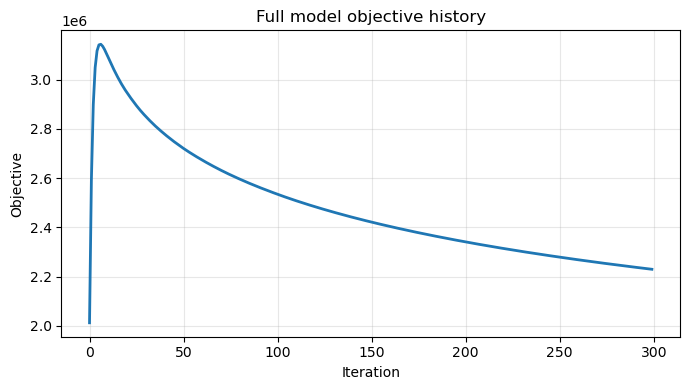

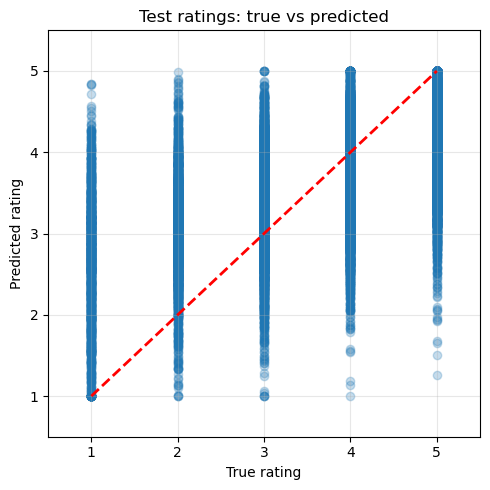

In [6]:
cfg = MovieLensConfig(
    data_dir=r"C:\Users\cdmas\Desktop\Numerical Experiment\ml-100k",
    sigma_for_lambda=1.0,
    c_lambda=5.0,
    lambda_multiplier=1.0,
    max_iter=300,
    tol=1e-6,
    verbose=True,
)

M_hat, M_hat_clip, info, results, W, Z, Y_train, train_mask, Y_test, test_mask = run_full_model_movielens(cfg)
print(results)